In [ ]:
!pip install streamlit torch torchvision -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 98.2 MB/s eta 0:00:00


**Vanilla GAN**

In [ ]:
!pip install torch torchvision matplotlib -q

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
#Configuration
LATENT_DIM   = 100
IMG_SIZE     = 784          # 28×28 flattened
HIDDEN       = 256
LR           = 2e-4
BATCH_SIZE   = 64
EPOCHS       = 50           # increase for better results

SAVE_PATH    = "vanilla_gan.pth"

DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [ ]:
#Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])      # → [-1, 1]
])
dataset = torchvision.datasets.MNIST(root="./data", train=True,
                                     download=True, transform=transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.29MB/s]


In [ ]:
#Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN, HIDDEN * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN * 2, HIDDEN * 4),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN * 4, IMG_SIZE),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

In [ ]:
#Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_SIZE, HIDDEN * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN * 4, HIDDEN * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN * 2, HIDDEN),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
#Init
G   = Generator().to(DEVICE)
D   = Discriminator().to(DEVICE)
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

g_losses, d_losses = [], []

In [ ]:
#Training loop
for epoch in range(EPOCHS):
    g_epoch, d_epoch = [], []
    for real_imgs, _ in loader:
        batch = real_imgs.size(0)
        real_imgs = real_imgs.view(batch, -1).to(DEVICE)

        real_labels = torch.ones(batch, 1).to(DEVICE)
        fake_labels = torch.zeros(batch, 1).to(DEVICE)

        #Train D
        z        = torch.randn(batch, LATENT_DIM).to(DEVICE)
        fake_imgs = G(z).detach()
        d_real   = criterion(D(real_imgs), real_labels)
        d_fake   = criterion(D(fake_imgs), fake_labels)
        d_loss   = (d_real + d_fake) / 2
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        #Train G
        z        = torch.randn(batch, LATENT_DIM).to(DEVICE)
        fake_imgs = G(z)
        g_loss   = criterion(D(fake_imgs), real_labels)   # fool D
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

        g_epoch.append(g_loss.item())
        d_epoch.append(d_loss.item())

    g_losses.append(np.mean(g_epoch))
    d_losses.append(np.mean(d_epoch))

    # Discriminator accuracy on this epoch
    with torch.no_grad():
        z         = torch.randn(1000, LATENT_DIM).to(DEVICE)
        fake_out  = D(G(z))
        real_sample = next(iter(loader))[0][:1000].view(-1, IMG_SIZE).to(DEVICE)
        real_out  = D(real_sample)
        correct   = ((real_out > 0.5).float().sum() +
                     (fake_out < 0.5).float().sum()).item()
        acc = correct / 2000 * 100

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]  "
              f"G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}  "
              f"D-Acc: {acc:.1f}%")

Epoch [10/50]  G: 1.3033  D: 0.5070  D-Acc: 38.2%
Epoch [20/50]  G: 1.1989  D: 0.5372  D-Acc: 37.8%
Epoch [30/50]  G: 1.1538  D: 0.5546  D-Acc: 41.3%
Epoch [40/50]  G: 1.1154  D: 0.5637  D-Acc: 38.1%
Epoch [50/50]  G: 1.0928  D: 0.5696  D-Acc: 46.3%


In [ ]:
#Save
torch.save({
    "G": G.state_dict(),
    "D": D.state_dict(),
    "g_losses": g_losses,
    "d_losses": d_losses,
    "acc": acc,
    "config": {"latent_dim": LATENT_DIM, "hidden": HIDDEN},
}, SAVE_PATH)
print(f"\nSaved → {SAVE_PATH}")


Saved → vanilla_gan.pth


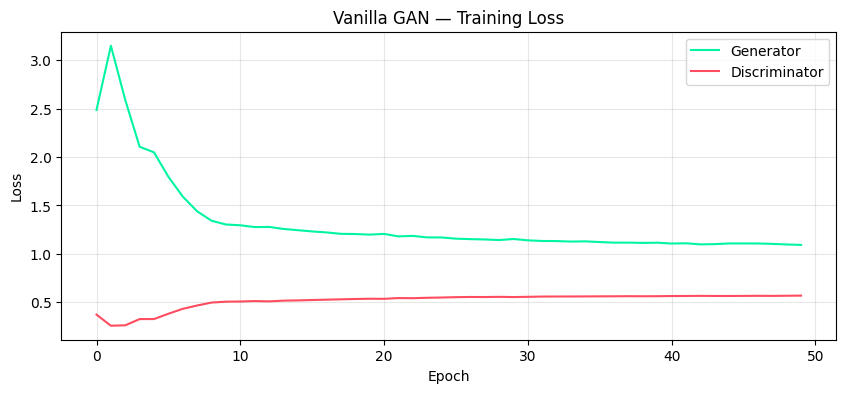

In [ ]:
#Plot loss
plt.figure(figsize=(10, 4))
plt.plot(g_losses, label="Generator", color="#00f5a0")
plt.plot(d_losses, label="Discriminator", color="#ff4c60")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Vanilla GAN — Training Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

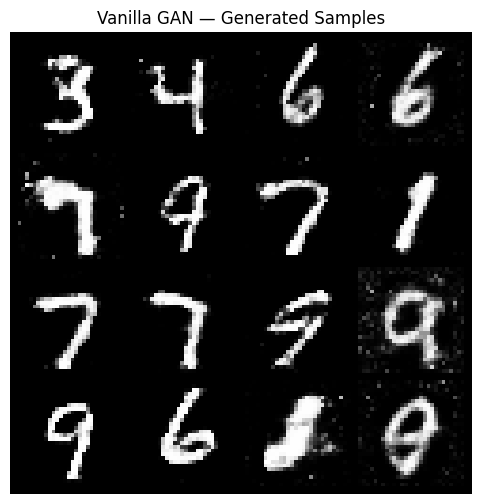

In [ ]:
#Sample images
G.eval()
with torch.no_grad():
    z    = torch.randn(16, LATENT_DIM).to(DEVICE)
    imgs = G(z).view(-1, 1, 28, 28).cpu()
    grid = torchvision.utils.make_grid(imgs, nrow=4, normalize=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off")
    plt.title("Vanilla GAN — Generated Samples")
    plt.show()

**C Gan**

In [ ]:
#Configuration
LATENT_DIM   = 100
NUM_CLASSES  = 10
EMBED_DIM    = 50
IMG_SIZE     = 784
HIDDEN       = 256
LR           = 2e-4
BATCH_SIZE   = 64
EPOCHS       = 50
SAVE_PATH    = "cgan.pth"
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [ ]:
#Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, EMBED_DIM)
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM + EMBED_DIM, HIDDEN),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN, HIDDEN * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN * 2, HIDDEN * 4),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN * 4, IMG_SIZE),
            nn.Tanh()
        )
    def forward(self, z, labels):
        emb = self.label_emb(labels)            # (B, EMBED_DIM)
        x   = torch.cat([z, emb], dim=1)        # (B, LATENT_DIM + EMBED_DIM)
        return self.net(x)

In [ ]:
#Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, EMBED_DIM)
        self.net = nn.Sequential(
            nn.Linear(IMG_SIZE + EMBED_DIM, HIDDEN * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN * 4, HIDDEN * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN * 2, HIDDEN),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN, 1),
            nn.Sigmoid()
        )
    def forward(self, x, labels):
        emb = self.label_emb(labels)
        inp = torch.cat([x, emb], dim=1)
        return self.net(inp)

In [ ]:
#Init
G   = Generator().to(DEVICE)
D   = Discriminator().to(DEVICE)
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

g_losses, d_losses = [], []

In [ ]:
#Training loop
for epoch in range(EPOCHS):
    g_epoch, d_epoch = [], []
    for real_imgs, labels in loader:
        batch      = real_imgs.size(0)
        real_imgs  = real_imgs.view(batch, -1).to(DEVICE)
        labels     = labels.to(DEVICE)

        real_lbl = torch.ones(batch, 1).to(DEVICE)
        fake_lbl = torch.zeros(batch, 1).to(DEVICE)

        #Train D
        z         = torch.randn(batch, LATENT_DIM).to(DEVICE)
        fake_imgs = G(z, labels).detach()
        d_real    = criterion(D(real_imgs, labels), real_lbl)
        d_fake    = criterion(D(fake_imgs, labels), fake_lbl)
        d_loss    = (d_real + d_fake) / 2
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        #Train G
        z         = torch.randn(batch, LATENT_DIM).to(DEVICE)
        fake_imgs = G(z, labels)
        g_loss    = criterion(D(fake_imgs, labels), real_lbl)
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

        g_epoch.append(g_loss.item())
        d_epoch.append(d_loss.item())

    g_losses.append(np.mean(g_epoch))
    d_losses.append(np.mean(d_epoch))

    # Discriminator accuracy
    with torch.no_grad():
        z_t       = torch.randn(1000, LATENT_DIM).to(DEVICE)
        lbl_t     = torch.randint(0, NUM_CLASSES, (1000,)).to(DEVICE)
        fake_out  = D(G(z_t, lbl_t), lbl_t)
        real_b, lbl_b = next(iter(loader))
        real_b    = real_b[:1000].view(-1, IMG_SIZE).to(DEVICE)
        lbl_b     = lbl_b[:1000].to(DEVICE)
        real_out  = D(real_b, lbl_b)
        correct   = ((real_out > 0.5).sum() + (fake_out < 0.5).sum()).item()
        acc       = correct / 2000 * 100

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]  "
              f"G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}  "
              f"D-Acc: {acc:.1f}%")

Epoch [10/50]  G: 8.9736  D: 0.0154  D-Acc: 53.2%
Epoch [20/50]  G: 12.0797  D: 0.0001  D-Acc: 53.2%
Epoch [30/50]  G: 9.0959  D: 0.0057  D-Acc: 53.2%
Epoch [40/50]  G: 14.7166  D: 0.0000  D-Acc: 53.2%
Epoch [50/50]  G: 18.1579  D: 0.0000  D-Acc: 53.2%


In [ ]:
#save
torch.save({
    "G": G.state_dict(),
    "D": D.state_dict(),
    "g_losses": g_losses,
    "d_losses": d_losses,
    "acc": acc,
    "config": {"latent_dim": LATENT_DIM, "embed_dim": EMBED_DIM,
                "num_classes": NUM_CLASSES, "hidden": HIDDEN},
}, SAVE_PATH)
print(f"\nSaved → {SAVE_PATH}")


Saved → cgan.pth


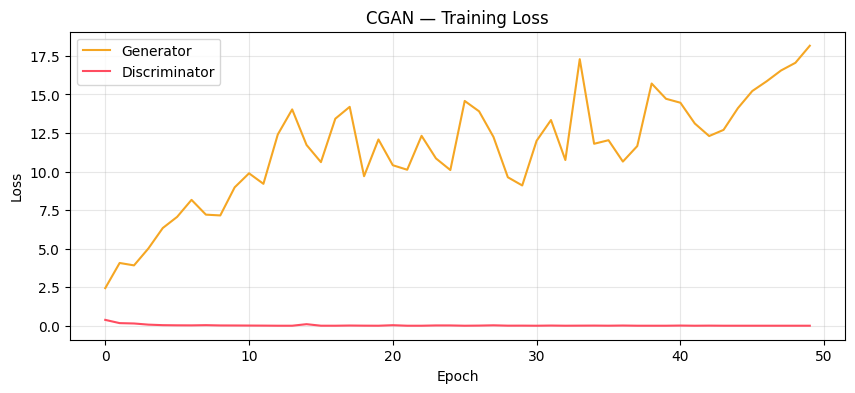

In [ ]:
#plot loss
plt.figure(figsize=(10, 4))
plt.plot(g_losses, label="Generator", color="#f5a623")
plt.plot(d_losses, label="Discriminator", color="#ff4c60")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("CGAN — Training Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

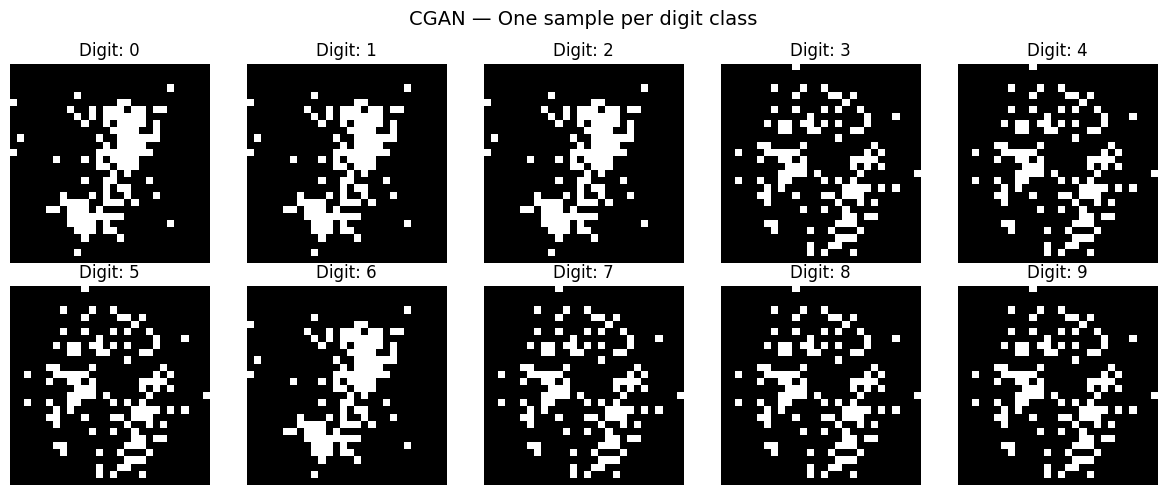

In [ ]:
#Sample: one row per class
G.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("CGAN — One sample per digit class", fontsize=14)
with torch.no_grad():
    for digit in range(10):
        z   = torch.randn(1, LATENT_DIM).to(DEVICE)
        lbl = torch.tensor([digit]).to(DEVICE)
        img = G(z, lbl).view(28, 28).cpu().numpy()
        ax  = axes[digit // 5][digit % 5]
        ax.imshow(img, cmap="gray"); ax.set_title(f"Digit: {digit}")
        ax.axis("off")
plt.tight_layout(); plt.show()

**DC GAN**

In [ ]:
#Configuration
LATENT_DIM  = 128
FEATURE_G   = 64        # base feature maps for Generator
FEATURE_D   = 64        # base feature maps for Discriminator
CHANNELS    = 1         # grayscale
LR          = 2e-4
BATCH_SIZE  = 64
EPOCHS      = 50
SAVE_PATH   = "dcgan.pth"
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [ ]:
#Weight initialization (DCGAN paper convention)
def weights_init(m):
    cls = m.__class__.__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
#Generator
# z (B, 128, 1, 1) → (B, 1, 32, 32)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # (B, 128, 1, 1)
            nn.ConvTranspose2d(LATENT_DIM,  FEATURE_G * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(FEATURE_G * 8), nn.ReLU(True),
            # → (B, 512, 4, 4)
            nn.ConvTranspose2d(FEATURE_G * 8, FEATURE_G * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(FEATURE_G * 4), nn.ReLU(True),
            # → (B, 256, 8, 8)
            nn.ConvTranspose2d(FEATURE_G * 4, FEATURE_G * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(FEATURE_G * 2), nn.ReLU(True),
            # → (B, 128, 16, 16)
            nn.ConvTranspose2d(FEATURE_G * 2, CHANNELS,      4, 2, 1, bias=False),
            nn.Tanh()
            # → (B, 1, 32, 32)
        )
        self.apply(weights_init)

    def forward(self, z):
        return self.net(z)

In [ ]:
#Discriminator
# (B, 1, 32, 32) → (B, 1)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # (B, 1, 32, 32)
            nn.Conv2d(CHANNELS,      FEATURE_D,     4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # → (B, 64, 16, 16)
            nn.Conv2d(FEATURE_D,     FEATURE_D * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(FEATURE_D * 2), nn.LeakyReLU(0.2, inplace=True),
            # → (B, 128, 8, 8)
            nn.Conv2d(FEATURE_D * 2, FEATURE_D * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(FEATURE_D * 4), nn.LeakyReLU(0.2, inplace=True),
            # → (B, 256, 4, 4)
            nn.Conv2d(FEATURE_D * 4, 1,             4, 1, 0, bias=False),
            nn.Sigmoid()
            # → (B, 1, 1, 1)
        )
        self.apply(weights_init)

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
#initialization
G   = Generator().to(DEVICE)
D   = Discriminator().to(DEVICE)
opt_G     = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D     = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# Fixed noise for consistent visual progress
fixed_z = torch.randn(16, LATENT_DIM, 1, 1).to(DEVICE)
g_losses, d_losses = [], []

In [ ]:
import torch.nn.functional as F

#Training loop
for epoch in range(EPOCHS):
    g_epoch, d_epoch = [], []
    for real_imgs, _ in loader:
        batch     = real_imgs.size(0)
        # Resize real_imgs to 32x32 to match discriminator's expected input
        real_imgs = F.interpolate(real_imgs, size=(32, 32), mode='bilinear', align_corners=False).to(DEVICE)

        real_lbl = torch.ones(batch, 1).to(DEVICE)
        fake_lbl = torch.zeros(batch, 1).to(DEVICE)

        # ── Train D ─────────────────────
        z         = torch.randn(batch, LATENT_DIM, 1, 1).to(DEVICE)
        fake_imgs = G(z).detach()
        d_real    = criterion(D(real_imgs), real_lbl)
        d_fake    = criterion(D(fake_imgs), fake_lbl)
        d_loss    = (d_real + d_fake) / 2
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        # ── Train G ─────────────────────
        z         = torch.randn(batch, LATENT_DIM, 1, 1).to(DEVICE)
        fake_imgs = G(z)
        g_loss    = criterion(D(fake_imgs), real_lbl)
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

        g_epoch.append(g_loss.item())
        d_epoch.append(d_loss.item())

    g_losses.append(np.mean(g_epoch))
    d_losses.append(np.mean(d_epoch))

    # Discriminator accuracy
    with torch.no_grad():
        z_t      = torch.randn(512, LATENT_DIM, 1, 1).to(DEVICE)
        fake_out = D(G(z_t))
        real_b   = next(iter(loader))[0][:512]
        # Resize real_b for accuracy calculation as well
        real_b    = F.interpolate(real_b, size=(32, 32), mode='bilinear', align_corners=False).to(DEVICE)
        real_out = D(real_b)
        correct  = ((real_out > 0.5).sum() + (fake_out < 0.5).sum()).item()
        acc      = correct / 1024 * 100

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]  "
              f"G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}  "
              f"D-Acc: {acc:.1f}%")

Epoch [10/50]  G: 3.6232  D: 0.1587  D-Acc: 56.2%
Epoch [20/50]  G: 4.5921  D: 0.1005  D-Acc: 56.2%
Epoch [30/50]  G: 7.5741  D: 0.0015  D-Acc: 56.2%
Epoch [40/50]  G: 7.4861  D: 0.0018  D-Acc: 56.2%
Epoch [50/50]  G: 7.5112  D: 0.0024  D-Acc: 56.2%


In [ ]:
#save
torch.save({
    "G": G.state_dict(),
    "D": D.state_dict(),
    "g_losses": g_losses,
    "d_losses": d_losses,
    "acc": acc,
    "config": {"latent_dim": LATENT_DIM, "feature_g": FEATURE_G,
                "feature_d": FEATURE_D, "channels": CHANNELS},
}, SAVE_PATH)
print(f"\nSaved → {SAVE_PATH}")


Saved → dcgan.pth


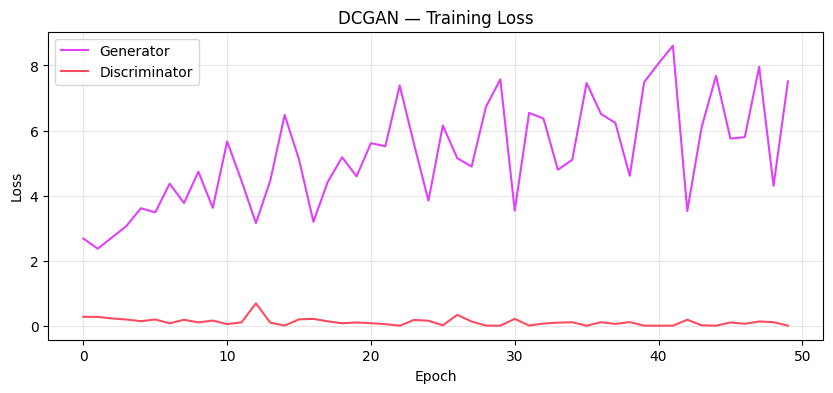

In [ ]:
#plot loss
plt.figure(figsize=(10, 4))
plt.plot(g_losses, label="Generator", color="#e040fb")
plt.plot(d_losses, label="Discriminator", color="#ff4c60")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("DCGAN — Training Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

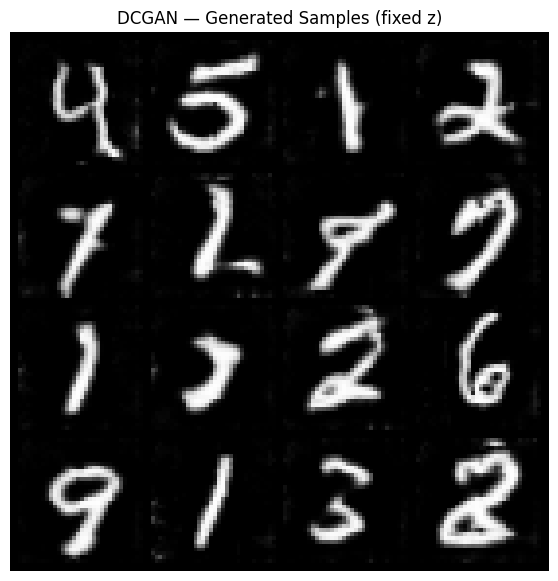

In [ ]:
#Sample with fixed noise
G.eval()
with torch.no_grad():
    imgs = G(fixed_z).cpu()
    grid = torchvision.utils.make_grid(imgs, nrow=4, normalize=True)
    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off"); plt.title("DCGAN — Generated Samples (fixed z)")
    plt.show()

**Launch Gradio**

In [ ]:
!pip install gradio torch torchvision -q

In [ ]:
app_code = """
import gradio as gr
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class VanillaG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100,256),nn.LeakyReLU(0.2),
            nn.Linear(256,512),nn.LeakyReLU(0.2),
            nn.Linear(512,1024),nn.LeakyReLU(0.2),
            nn.Linear(1024,784),nn.Tanh())
    def forward(self,z): return self.net(z)

class VanillaD(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,1024),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(1024,512),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(512,256),nn.LeakyReLU(0.2),
            nn.Linear(256,1),nn.Sigmoid())
    def forward(self,x): return self.net(x)

class CGANG(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10,50)
        self.net = nn.Sequential(
            nn.Linear(150,256),nn.LeakyReLU(0.2),
            nn.Linear(256,512),nn.LeakyReLU(0.2),
            nn.Linear(512,1024),nn.LeakyReLU(0.2),
            nn.Linear(1024,784),nn.Tanh())
    def forward(self,z,lbl):
        return self.net(torch.cat([z,self.label_emb(lbl)],1))

class CGAND(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10,50)
        self.net = nn.Sequential(
            nn.Linear(834,1024),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(1024,512),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(512,256),nn.LeakyReLU(0.2),
            nn.Linear(256,1),nn.Sigmoid())
    def forward(self,x,lbl):
        return self.net(torch.cat([x,self.label_emb(lbl)],1))

class DCGANG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),nn.ReLU(True),
            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),nn.ReLU(True),
            nn.ConvTranspose2d(128,1,4,2,1,bias=False),nn.Tanh())
    def forward(self,z): return self.net(z)

class DCGAND(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,64,4,2,1,bias=False),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(64,128,4,2,1,bias=False),nn.BatchNorm2d(128),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(128,256,4,2,1,bias=False),nn.BatchNorm2d(256),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(256,1,4,1,0,bias=False),nn.Sigmoid())
    def forward(self,x): return self.net(x).view(-1,1)


def load_models():
    models = {}
    for name, path, G_cls, D_cls in [
        ("Vanilla GAN", "vanilla_gan.pth", VanillaG, VanillaD),
        ("CGAN",        "cgan.pth",        CGANG,    CGAND),
        ("DCGAN",       "dcgan.pth",       DCGANG,   DCGAND),
    ]:
        if os.path.exists(path):
            try:
                ckpt = torch.load(path, map_location=DEVICE)
                G = G_cls().to(DEVICE)
                G.load_state_dict(ckpt["G"])
                G.eval()
                D = D_cls().to(DEVICE)
                D.load_state_dict(ckpt["D"])
                D.eval()
                models[name] = {
                    "G": G, "D": D,
                    "acc":      ckpt.get("acc", 0),
                    "g_losses": ckpt.get("g_losses", []),
                    "d_losses": ckpt.get("d_losses", []),
                    "loaded":   True,
                }
            except Exception as e:
                models[name] = {"loaded": False, "acc": 0, "g_losses": [], "d_losses": []}
        else:
            models[name] = {"loaded": False, "acc": 0, "g_losses": [], "d_losses": []}
    return models

MODELS = load_models()


def tensor_to_pil(t, is_conv=False):
    t   = t.squeeze().detach().cpu()
    arr = ((t.numpy() + 1) / 2 * 255).clip(0, 255).astype("uint8")
    if is_conv:
        img = Image.fromarray(arr, mode="L").resize((128,128), Image.NEAREST)
    else:
        img = Image.fromarray(arr.reshape(28,28), mode="L").resize((128,128), Image.NEAREST)
    return img.convert("RGB")


def generate_images(model_name, n_images, digit):
    m = MODELS.get(model_name)
    if not m or not m["loaded"]:
        return [], "ERROR: " + model_name + " weights not found. Train the model first."
    imgs = []
    with torch.no_grad():
        for _ in range(int(n_images)):
            if model_name == "Vanilla GAN":
                z = torch.randn(1, 100).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z)))
            elif model_name == "CGAN":
                z   = torch.randn(1, 100).to(DEVICE)
                lbl = torch.tensor([int(digit)]).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z, lbl)))
            else:
                z = torch.randn(1, 128, 1, 1).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z), is_conv=True))
    acc  = m["acc"]
    info = "Generated " + str(len(imgs)) + " images using " + model_name + "\\n"
    info += "Discriminator Accuracy: " + str(round(acc, 1)) + "%\\n"
    info += "Device: " + str(DEVICE)
    return imgs, info


def classify_image(model_name, image):
    if image is None:
        return "Please upload an image first."
    m = MODELS.get(model_name)
    if not m or not m["loaded"]:
        return "ERROR: " + model_name + " weights not found. Train the model first."
    size = 32 if model_name == "DCGAN" else 28
    img  = Image.fromarray(image).convert("L").resize((size, size))
    arr  = np.array(img).astype(np.float32) / 127.5 - 1.0
    with torch.no_grad():
        if model_name == "DCGAN":
            t   = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(DEVICE)
            out = m["D"](t).item()
        elif model_name == "CGAN":
            t   = torch.tensor(arr.flatten()).unsqueeze(0).to(DEVICE)
            lbl = torch.zeros(1, dtype=torch.long).to(DEVICE)
            out = m["D"](t, lbl).item()
        else:
            t   = torch.tensor(arr.flatten()).unsqueeze(0).to(DEVICE)
            out = m["D"](t).item()
    label      = "REAL" if out > 0.5 else "FAKE"
    confidence = round(max(out, 1 - out) * 100, 1)
    icon       = "YES" if label == "REAL" else "NO"
    result  = "Prediction  : " + icon + " " + label + "\\n"
    result += "Confidence  : " + str(confidence) + "%\\n"
    result += "D(x) score  : " + str(round(out, 4)) + "\\n"
    result += "Model used  : " + model_name
    return result


def load_epoch_images(model_name):
    folder = "epoch_imgs/" + model_name.replace(" ", "_")
    if not os.path.exists(folder):
        return [], "No epoch images found. Train the model first."
    files = sorted([f for f in os.listdir(folder) if f.endswith(".png")])
    if not files:
        return [], "Folder exists but no images inside."
    imgs = []
    for f in files:
        ep  = f.replace("epoch_", "").replace(".png", "").lstrip("0") or "0"
        img = Image.open(os.path.join(folder, f)).convert("RGB")
        imgs.append((img, "Epoch " + ep))
    return imgs, str(len(imgs)) + " checkpoints loaded for " + model_name


def plot_loss(model_name):
    m   = MODELS.get(model_name)
    g_l = m.get("g_losses", []) if m else []
    d_l = m.get("d_losses", []) if m else []
    colors = {"Vanilla GAN": "#00f5a0", "CGAN": "#f5a623", "DCGAN": "#e040fb"}
    c      = colors.get(model_name, "#00f5a0")
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor("#0d0d1a")
    ax.set_facecolor("#0a0a12")
    if not g_l or not d_l:
        ax.text(0.5, 0.5, "No loss data. Train the model first.",
                ha="center", va="center", fontsize=13,
                color="#888", transform=ax.transAxes)
    else:
        ax.plot(g_l, color=c,         label="Generator",     linewidth=2)
        ax.plot(d_l, color="#ff4c60", label="Discriminator", linewidth=2)
        ax.legend(facecolor="#0d0d1a", labelcolor="white", edgecolor="#333")
    ax.set_xlabel("Epoch", color="#aaa")
    ax.set_ylabel("Loss",  color="#aaa")
    ax.set_title(model_name + " Training Loss", color="#ddd", pad=12)
    ax.tick_params(colors="#666")
    for spine in ax.spines.values():
        spine.set_color("#1a1a2e")
    ax.grid(alpha=0.15, color="#333")
    plt.tight_layout()
    return fig


def load_progress(model_name):
    imgs, info = load_epoch_images(model_name)
    fig        = plot_loss(model_name)
    return imgs, info, fig


def get_summary():
    rows = []
    for name, m in MODELS.items():
        status = "Loaded" if m["loaded"] else "Not trained"
        acc    = str(round(m["acc"], 1)) + "%" if m["loaded"] else "N/A"
        epochs = str(len(m.get("g_losses", [])))
        rows.append([name, status, acc, epochs])
    return rows


with gr.Blocks(title="GAN Lab") as demo:

    gr.Markdown("# GAN Lab")
    gr.Markdown("Vanilla GAN | CGAN | DCGAN")

    with gr.Tab("Generate"):
        gr.Markdown("### Generate images from trained Generator")
        with gr.Row():
            with gr.Column(scale=1):
                gen_model  = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                          value="Vanilla GAN", label="Model")
                n_images   = gr.Slider(1, 8, value=4, step=1, label="Number of Images")
                gen_digit  = gr.Dropdown(list(range(10)), value=0,
                                          label="Condition Label (CGAN only)")
                gen_btn    = gr.Button("Generate", variant="primary")
                gen_info   = gr.Textbox(label="Info", lines=3, interactive=False)
            with gr.Column(scale=2):
                gen_gallery = gr.Gallery(label="Generated Images",
                                          columns=4, height=400, object_fit="contain")
        gen_btn.click(fn=generate_images,
                      inputs=[gen_model, n_images, gen_digit],
                      outputs=[gen_gallery, gen_info])

    with gr.Tab("Classify"):
        gr.Markdown("### Discriminator predicts Real or Fake")
        with gr.Row():
            with gr.Column(scale=1):
                cls_model  = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                          value="Vanilla GAN", label="Model")
                cls_input  = gr.Image(label="Upload Image", type="numpy", height=280)
                cls_btn    = gr.Button("Classify", variant="primary")
            with gr.Column(scale=1):
                cls_output = gr.Textbox(label="Result", lines=6, interactive=False)
        cls_btn.click(fn=classify_image,
                      inputs=[cls_model, cls_input],
                      outputs=cls_output)

    with gr.Tab("Training Progress"):
        gr.Markdown("### Epoch snapshots and loss curve")
        with gr.Row():
            prog_model = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                      value="Vanilla GAN", label="Model")
            prog_btn   = gr.Button("Load", variant="primary")
        prog_info    = gr.Textbox(label="Status", lines=1, interactive=False)
        prog_gallery = gr.Gallery(label="Epoch Snapshots",
                                   columns=5, height=300, object_fit="contain")
        prog_plot    = gr.Plot(label="Loss Curve")
        prog_btn.click(fn=load_progress,
                       inputs=prog_model,
                       outputs=[prog_gallery, prog_info, prog_plot])

    with gr.Tab("Model Summary"):
        gr.Markdown("### All model statuses")
        summary_btn   = gr.Button("Refresh", variant="primary")
        summary_table = gr.Dataframe(
            headers=["Model", "Status", "D Accuracy", "Epochs Trained"],
            value=get_summary(),
            interactive=False)
        summary_btn.click(fn=get_summary, outputs=summary_table)

demo.launch(share=True, quiet=False)
"""

with open("gan_app.py", "w") as f:
    f.write(app_code)

print("gan_app.py written successfully")

gan_app.py written successfully
Now run the next cell to launch


In [ ]:
#Launch
import subprocess, sys
subprocess.run([sys.executable, "gan_app.py"])

  Stopping...


KeyboardInterrupt: 

**Deployment on HuggingFace**

In [2]:
!pip install huggingface_hub -q

In [1]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Step 3 — Create repo and upload
from huggingface_hub import HfApi
import shutil, os

api = HfApi()

# Create the Space
api.create_repo(
    repo_id="realsuyash/gan-lab",   # change your-username
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True
)

# Upload app file
api.upload_file(
    path_or_fileobj="gan_app.py",
    path_in_repo="app.py",             # HF Spaces needs it named app.py
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)

# Upload model weights
for f in ["vanilla_gan.pth", "cgan.pth", "dcgan.pth"]:
    api.upload_file(
        path_or_fileobj=f,
        path_in_repo=f,
        repo_id="realsuyash/gan-lab",
        repo_type="space"
    )

# Upload requirements
with open("requirements.txt", "w") as f:
    f.write("torch\ntorchvision\ngradio\n")

api.upload_file(
    path_or_fileobj="requirements.txt",
    path_in_repo="requirements.txt",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)

print("Done! Visit: https://huggingface.co/spaces/realsuyash/gan-lab")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vanilla_gan.pth             :   5%|4         |  555kB / 11.8MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  cgan.pth                    :  32%|###2      | 3.89MB / 12.1MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  dcgan.pth                   :  22%|##2       | 3.86MB / 17.4MB            

Done! Visit: https://huggingface.co/spaces/realsuyash/gan-lab


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

with open("requirements.txt", "w") as f:
    f.write("torch\ntorchvision\ngradio\nmatplotlib\nnumpy\nPillow\n")

api.upload_file(
    path_or_fileobj="requirements.txt",
    path_in_repo="requirements.txt",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)

print("Done")

Done


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

for f in ["vanilla_gan.pth", "cgan.pth", "dcgan.pth"]:
    print(f"Uploading {f}...")
    api.upload_file(
        path_or_fileobj=f,
        path_in_repo=f,
        repo_id="realsuyash/gan-lab",
        repo_type="space"
    )
    print(f"Done: {f}")

print("All weights uploaded")

Uploading vanilla_gan.pth...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vanilla_gan.pth             : 100%|##########| 11.8MB / 11.8MB            

No files have been modified since last commit. Skipping to prevent empty commit.


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  dcgan.pth                   : 100%|##########| 17.4MB / 17.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Done: dcgan.pth
All weights uploaded


In [ ]:
from huggingface_hub import HfApi

api = HfApi()
files = api.list_repo_files(repo_id="realsuyash/gan-lab", repo_type="space")
for f in files:
    print(f)

.gitattributes
README.md
app.py
cgan.pth
dcgan.pth
requirements.txt
vanilla_gan.pth


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

# Force restart by touching the app file
api.restart_space(repo_id="realsuyash/gan-lab")
print("Space restarting...")

Space restarting...


In [ ]:
from huggingface_hub import HfApi, hf_hub_download

api = HfApi()

# Download app.py from the Space
path = hf_hub_download(
    repo_id="realsuyash/gan-lab",
    filename="app.py",
    repo_type="space"
)

# Read it
with open(path, "r") as f:
    code = f.read()

print("Downloaded app.py — length:", len(code))
print("First 200 chars:", code[:200])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


app.py: 0.00B [00:00, ?B/s]

Downloaded app.py — length: 12108
First 200 chars: 
import gradio as gr
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

DEVICE = torch.devic


In [ ]:
# Step 1 — Login again
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# Step 2 — Verify login works
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '64535af2a81144a8caded405', 'name': 'realsuyash', 'fullname': 'Suyash Khandare', 'email': 'yoyosuyashking@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1775001600, 'isPro': False, 'avatarUrl': '/avatars/ec8b2360537c901b5dc4b5d1faa3a1bd.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'GAN', 'role': 'write', 'createdAt': '2026-03-12T18:56:56.168Z'}}}


In [ ]:
# Step 3 — Download, patch, reupload
from huggingface_hub import HfApi, hf_hub_download

api = HfApi()

path = hf_hub_download(
    repo_id="realsuyash/gan-lab",
    filename="app.py",
    repo_type="space"
)

with open(path, "r") as f:
    code = f.read()

debug_line = """
import os
print("=== FILES IN RUNTIME ===")
for f in os.listdir("."):
    print(f)
print("vanilla_gan.pth exists:", os.path.exists("vanilla_gan.pth"))
print("cgan.pth exists:", os.path.exists("cgan.pth"))
print("dcgan.pth exists:", os.path.exists("dcgan.pth"))
print("========================")
"""

code = code.replace("import gradio as gr", "import gradio as gr\n" + debug_line, 1)

with open("/tmp/app.py", "w") as f:
    f.write(code)

api.upload_file(
    path_or_fileobj="/tmp/app.py",
    path_in_repo="app.py",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)
print("Done — check Logs tab on Space in 1 min")

Done — check Logs tab on Space in 1 min


In [ ]:
from huggingface_hub import HfApi, hf_hub_download

api = HfApi()

path = hf_hub_download(
    repo_id="realsuyash/gan-lab",
    filename="app.py",
    repo_type="space"
)

with open(path, "r") as f:
    code = f.read()

# Remove the debug lines we added
code = code.replace("""
import os
print("=== FILES IN RUNTIME ===")
for f in os.listdir("."):
    print(f)
print("vanilla_gan.pth exists:", os.path.exists("vanilla_gan.pth"))
print("cgan.pth exists:", os.path.exists("cgan.pth"))
print("dcgan.pth exists:", os.path.exists("dcgan.pth"))
print("========================")
""", "")

# Fix: reload models inside get_summary instead of using cached MODELS
code = code.replace(
    "def get_summary():\n    rows = []\n    for name, m in MODELS.items():",
    "def get_summary():\n    MODELS = load_models()\n    rows = []\n    for name, m in MODELS.items():"
)

with open("/tmp/app.py", "w") as f:
    f.write(code)

api.upload_file(
    path_or_fileobj="/tmp/app.py",
    path_in_repo="app.py",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)
print("Done — wait 1 min then click Refresh on Model Summary tab")

app.py: 0.00B [00:00, ?B/s]

Done — wait 1 min then click Refresh on Model Summary tab


In [ ]:
from huggingface_hub import HfApi, hf_hub_download

api = HfApi()

# Download current app.py
path = hf_hub_download(
    repo_id="realsuyash/gan-lab",
    filename="app.py",
    repo_type="space"
)

with open(path, "r") as f:
    code = f.read()

# Move MODELS loading inside each function instead of global
code = code.replace(
    "MODELS = load_models()\n",
    "# MODELS loaded per function\n"
)

code = code.replace(
    "def generate_images(model_name, n_images, digit):\n    m = MODELS.get(model_name)",
    "def generate_images(model_name, n_images, digit):\n    MODELS = load_models()\n    m = MODELS.get(model_name)"
)

code = code.replace(
    "def classify_image(model_name, image):\n    if image is None:",
    "def classify_image(model_name, image):\n    MODELS = load_models()\n    if image is None:"
)

code = code.replace(
    "def plot_loss(model_name):\n    m   = MODELS.get(model_name)",
    "def plot_loss(model_name):\n    MODELS = load_models()\n    m   = MODELS.get(model_name)"
)

with open("/tmp/app.py", "w") as f:
    f.write(code)

api.upload_file(
    path_or_fileobj="/tmp/app.py",
    path_in_repo="app.py",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)
print("Done")

app.py: 0.00B [00:00, ?B/s]

Done


In [ ]:
from huggingface_hub import HfApi, hf_hub_download

api = HfApi()

path = hf_hub_download(
    repo_id="realsuyash/gan-lab",
    filename="app.py",
    repo_type="space"
)

with open(path, "r") as f:
    code = f.read()

# Fix get_summary to load models itself
code = code.replace(
    "def get_summary():\n    rows = []",
    "def get_summary():\n    MODELS = load_models()\n    rows = []"
)

# Fix the value=get_summary() at startup — replace with empty list
code = code.replace(
    "value=get_summary(),",
    "value=[['Vanilla GAN','Loading...','N/A','0'],['CGAN','Loading...','N/A','0'],['DCGAN','Loading...','N/A','0']],"
)

with open("/tmp/app.py", "w") as f:
    f.write(code)

api.upload_file(
    path_or_fileobj="/tmp/app.py",
    path_in_repo="app.py",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)
print("Done — wait 1 min then click Refresh button on Model Summary tab")

app.py: 0.00B [00:00, ?B/s]

Done — wait 1 min then click Refresh button on Model Summary tab


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

app_code = """
import gradio as gr
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class VanillaG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100,256),nn.LeakyReLU(0.2),
            nn.Linear(256,512),nn.LeakyReLU(0.2),
            nn.Linear(512,1024),nn.LeakyReLU(0.2),
            nn.Linear(1024,784),nn.Tanh())
    def forward(self,z): return self.net(z)

class VanillaD(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,1024),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(1024,512),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(512,256),nn.LeakyReLU(0.2),
            nn.Linear(256,1),nn.Sigmoid())
    def forward(self,x): return self.net(x)

class CGANG(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10,50)
        self.net = nn.Sequential(
            nn.Linear(150,256),nn.LeakyReLU(0.2),
            nn.Linear(256,512),nn.LeakyReLU(0.2),
            nn.Linear(512,1024),nn.LeakyReLU(0.2),
            nn.Linear(1024,784),nn.Tanh())
    def forward(self,z,lbl):
        return self.net(torch.cat([z,self.label_emb(lbl)],1))

class CGAND(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10,50)
        self.net = nn.Sequential(
            nn.Linear(834,1024),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(1024,512),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(512,256),nn.LeakyReLU(0.2),
            nn.Linear(256,1),nn.Sigmoid())
    def forward(self,x,lbl):
        return self.net(torch.cat([x,self.label_emb(lbl)],1))

class DCGANG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),nn.ReLU(True),
            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),nn.ReLU(True),
            nn.ConvTranspose2d(128,1,4,2,1,bias=False),nn.Tanh())
    def forward(self,z): return self.net(z)

class DCGAND(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,64,4,2,1,bias=False),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(64,128,4,2,1,bias=False),nn.BatchNorm2d(128),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(128,256,4,2,1,bias=False),nn.BatchNorm2d(256),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(256,1,4,1,0,bias=False),nn.Sigmoid())
    def forward(self,x): return self.net(x).view(-1,1)


def load_models():
    models = {}
    for name, path, G_cls, D_cls in [
        ("Vanilla GAN", "vanilla_gan.pth", VanillaG, VanillaD),
        ("CGAN",        "cgan.pth",        CGANG,    CGAND),
        ("DCGAN",       "dcgan.pth",       DCGANG,   DCGAND),
    ]:
        if os.path.exists(path):
            try:
                ckpt = torch.load(path, map_location=DEVICE)
                G = G_cls().to(DEVICE)
                G.load_state_dict(ckpt["G"])
                G.eval()
                D = D_cls().to(DEVICE)
                D.load_state_dict(ckpt["D"])
                D.eval()
                models[name] = {
                    "G": G, "D": D,
                    "acc":      ckpt.get("acc", 0),
                    "g_losses": ckpt.get("g_losses", []),
                    "d_losses": ckpt.get("d_losses", []),
                    "loaded":   True,
                }
            except Exception as e:
                models[name] = {"loaded": False, "acc": 0, "g_losses": [], "d_losses": []}
        else:
            models[name] = {"loaded": False, "acc": 0, "g_losses": [], "d_losses": []}
    return models


def tensor_to_pil(t, is_conv=False):
    t   = t.squeeze().detach().cpu()
    arr = ((t.numpy() + 1) / 2 * 255).clip(0, 255).astype("uint8")
    if is_conv:
        img = Image.fromarray(arr, mode="L").resize((128,128), Image.NEAREST)
    else:
        img = Image.fromarray(arr.reshape(28,28), mode="L").resize((128,128), Image.NEAREST)
    return img.convert("RGB")


def generate_images(model_name, n_images, digit):
    MODELS = load_models()
    m = MODELS.get(model_name)
    if not m or not m["loaded"]:
        return [], "ERROR: " + model_name + " weights not found."
    imgs = []
    with torch.no_grad():
        for _ in range(int(n_images)):
            if model_name == "Vanilla GAN":
                z = torch.randn(1, 100).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z)))
            elif model_name == "CGAN":
                z   = torch.randn(1, 100).to(DEVICE)
                lbl = torch.tensor([int(digit)]).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z, lbl)))
            else:
                z = torch.randn(1, 128, 1, 1).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z), is_conv=True))
    acc  = m["acc"]
    info = "Generated " + str(len(imgs)) + " images using " + model_name + "\\n"
    info += "Discriminator Accuracy: " + str(round(acc, 1)) + "%\\n"
    info += "Device: " + str(DEVICE)
    return imgs, info


def classify_image(model_name, image):
    MODELS = load_models()
    if image is None:
        return "Please upload an image first."
    m = MODELS.get(model_name)
    if not m or not m["loaded"]:
        return "ERROR: " + model_name + " weights not found."
    size = 32 if model_name == "DCGAN" else 28
    img  = Image.fromarray(image).convert("L").resize((size, size))
    arr  = np.array(img).astype(np.float32) / 127.5 - 1.0
    with torch.no_grad():
        if model_name == "DCGAN":
            t   = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(DEVICE)
            out = m["D"](t).item()
        elif model_name == "CGAN":
            t   = torch.tensor(arr.flatten()).unsqueeze(0).to(DEVICE)
            lbl = torch.zeros(1, dtype=torch.long).to(DEVICE)
            out = m["D"](t, lbl).item()
        else:
            t   = torch.tensor(arr.flatten()).unsqueeze(0).to(DEVICE)
            out = m["D"](t).item()
    label      = "REAL" if out > 0.5 else "FAKE"
    confidence = round(max(out, 1 - out) * 100, 1)
    icon       = "YES" if label == "REAL" else "NO"
    result  = "Prediction  : " + icon + " " + label + "\\n"
    result += "Confidence  : " + str(confidence) + "%\\n"
    result += "D(x) score  : " + str(round(out, 4)) + "\\n"
    result += "Model used  : " + model_name
    return result


def load_epoch_images(model_name):
    folder = "epoch_imgs/" + model_name.replace(" ", "_")
    if not os.path.exists(folder):
        return [], "No epoch images found. Train the model first."
    files = sorted([f for f in os.listdir(folder) if f.endswith(".png")])
    if not files:
        return [], "Folder exists but no images inside."
    imgs = []
    for f in files:
        ep  = f.replace("epoch_", "").replace(".png", "").lstrip("0") or "0"
        img = Image.open(os.path.join(folder, f)).convert("RGB")
        imgs.append((img, "Epoch " + ep))
    return imgs, str(len(imgs)) + " checkpoints loaded for " + model_name


def plot_loss(model_name):
    MODELS = load_models()
    m   = MODELS.get(model_name)
    g_l = m.get("g_losses", []) if m else []
    d_l = m.get("d_losses", []) if m else []
    colors = {"Vanilla GAN": "#00f5a0", "CGAN": "#f5a623", "DCGAN": "#e040fb"}
    c      = colors.get(model_name, "#00f5a0")
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor("#0d0d1a")
    ax.set_facecolor("#0a0a12")
    if not g_l or not d_l:
        ax.text(0.5, 0.5, "No loss data. Train the model first.",
                ha="center", va="center", fontsize=13,
                color="#888", transform=ax.transAxes)
    else:
        ax.plot(g_l, color=c,         label="Generator",     linewidth=2)
        ax.plot(d_l, color="#ff4c60", label="Discriminator", linewidth=2)
        ax.legend(facecolor="#0d0d1a", labelcolor="white", edgecolor="#333")
    ax.set_xlabel("Epoch", color="#aaa")
    ax.set_ylabel("Loss",  color="#aaa")
    ax.set_title(model_name + " Training Loss", color="#ddd", pad=12)
    ax.tick_params(colors="#666")
    for spine in ax.spines.values():
        spine.set_color("#1a1a2e")
    ax.grid(alpha=0.15, color="#333")
    plt.tight_layout()
    return fig


def load_progress(model_name):
    imgs, info = load_epoch_images(model_name)
    fig        = plot_loss(model_name)
    return imgs, info, fig


def get_summary():
    MODELS = load_models()
    rows = []
    for name, m in MODELS.items():
        status = "Loaded" if m["loaded"] else "Not trained"
        acc    = str(round(m["acc"], 1)) + "%" if m["loaded"] else "N/A"
        epochs = str(len(m.get("g_losses", [])))
        rows.append([name, status, acc, epochs])
    return rows


with gr.Blocks(title="GAN Lab") as demo:

    gr.Markdown("# GAN Lab")
    gr.Markdown("Vanilla GAN | CGAN | DCGAN")

    with gr.Tab("Generate"):
        gr.Markdown("### Generate images from trained Generator")
        with gr.Row():
            with gr.Column(scale=1):
                gen_model  = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                          value="Vanilla GAN", label="Model")
                n_images   = gr.Slider(1, 8, value=4, step=1, label="Number of Images")
                gen_digit  = gr.Dropdown(list(range(10)), value=0,
                                          label="Condition Label (CGAN only)")
                gen_btn    = gr.Button("Generate", variant="primary")
                gen_info   = gr.Textbox(label="Info", lines=3, interactive=False)
            with gr.Column(scale=2):
                gen_gallery = gr.Gallery(label="Generated Images",
                                          columns=4, height=400, object_fit="contain")
        gen_btn.click(fn=generate_images,
                      inputs=[gen_model, n_images, gen_digit],
                      outputs=[gen_gallery, gen_info])

    with gr.Tab("Classify"):
        gr.Markdown("### Discriminator predicts Real or Fake")
        with gr.Row():
            with gr.Column(scale=1):
                cls_model  = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                          value="Vanilla GAN", label="Model")
                cls_input  = gr.Image(label="Upload Image", type="numpy", height=280)
                cls_btn    = gr.Button("Classify", variant="primary")
            with gr.Column(scale=1):
                cls_output = gr.Textbox(label="Result", lines=6, interactive=False)
        cls_btn.click(fn=classify_image,
                      inputs=[cls_model, cls_input],
                      outputs=cls_output)

    with gr.Tab("Training Progress"):
        gr.Markdown("### Epoch snapshots and loss curve")
        with gr.Row():
            prog_model = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                      value="Vanilla GAN", label="Model")
            prog_btn   = gr.Button("Load", variant="primary")
        prog_info    = gr.Textbox(label="Status", lines=1, interactive=False)
        prog_gallery = gr.Gallery(label="Epoch Snapshots",
                                   columns=5, height=300, object_fit="contain")
        prog_plot    = gr.Plot(label="Loss Curve")
        prog_btn.click(fn=load_progress,
                       inputs=prog_model,
                       outputs=[prog_gallery, prog_info, prog_plot])

    with gr.Tab("Model Summary"):
        gr.Markdown("### All model statuses")
        summary_btn   = gr.Button("Refresh", variant="primary")
        summary_table = gr.Dataframe(
            headers=["Model", "Status", "D Accuracy", "Epochs Trained"],
            value=[["Vanilla GAN","Loading...","N/A","0"],
                   ["CGAN","Loading...","N/A","0"],
                   ["DCGAN","Loading...","N/A","0"]],
            interactive=False)
        summary_btn.click(fn=get_summary, outputs=summary_table)

demo.launch()
"""

with open("/tmp/app.py", "w") as f:
    f.write(app_code)

api.upload_file(
    path_or_fileobj="/tmp/app.py",
    path_in_repo="app.py",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)
print("Done — wait 1 min, then click Refresh on Model Summary tab")

Done — wait 1 min, then click Refresh on Model Summary tab


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

app_code = """
import gradio as gr
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Use absolute path — critical for HF Spaces
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class VanillaG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100,256),nn.LeakyReLU(0.2),
            nn.Linear(256,512),nn.LeakyReLU(0.2),
            nn.Linear(512,1024),nn.LeakyReLU(0.2),
            nn.Linear(1024,784),nn.Tanh())
    def forward(self,z): return self.net(z)

class VanillaD(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,1024),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(1024,512),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(512,256),nn.LeakyReLU(0.2),
            nn.Linear(256,1),nn.Sigmoid())
    def forward(self,x): return self.net(x)

class CGANG(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10,50)
        self.net = nn.Sequential(
            nn.Linear(150,256),nn.LeakyReLU(0.2),
            nn.Linear(256,512),nn.LeakyReLU(0.2),
            nn.Linear(512,1024),nn.LeakyReLU(0.2),
            nn.Linear(1024,784),nn.Tanh())
    def forward(self,z,lbl):
        return self.net(torch.cat([z,self.label_emb(lbl)],1))

class CGAND(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10,50)
        self.net = nn.Sequential(
            nn.Linear(834,1024),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(1024,512),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(512,256),nn.LeakyReLU(0.2),
            nn.Linear(256,1),nn.Sigmoid())
    def forward(self,x,lbl):
        return self.net(torch.cat([x,self.label_emb(lbl)],1))

class DCGANG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),nn.ReLU(True),
            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),nn.ReLU(True),
            nn.ConvTranspose2d(128,1,4,2,1,bias=False),nn.Tanh())
    def forward(self,z): return self.net(z)

class DCGAND(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,64,4,2,1,bias=False),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(64,128,4,2,1,bias=False),nn.BatchNorm2d(128),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(128,256,4,2,1,bias=False),nn.BatchNorm2d(256),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(256,1,4,1,0,bias=False),nn.Sigmoid())
    def forward(self,x): return self.net(x).view(-1,1)


def load_models():
    models = {}
    for name, path, G_cls, D_cls in [
        ("Vanilla GAN", os.path.join(BASE_DIR, "vanilla_gan.pth"), VanillaG, VanillaD),
        ("CGAN",        os.path.join(BASE_DIR, "cgan.pth"),        CGANG,    CGAND),
        ("DCGAN",       os.path.join(BASE_DIR, "dcgan.pth"),       DCGANG,   DCGAND),
    ]:
        if os.path.exists(path):
            try:
                ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
                G = G_cls().to(DEVICE)
                G.load_state_dict(ckpt["G"])
                G.eval()
                D = D_cls().to(DEVICE)
                D.load_state_dict(ckpt["D"])
                D.eval()
                models[name] = {
                    "G": G, "D": D,
                    "acc":      ckpt.get("acc", 0),
                    "g_losses": ckpt.get("g_losses", []),
                    "d_losses": ckpt.get("d_losses", []),
                    "loaded":   True,
                }
                print("Loaded: " + name)
            except Exception as e:
                print("Failed to load " + name + ": " + str(e))
                models[name] = {"loaded": False, "acc": 0, "g_losses": [], "d_losses": []}
        else:
            print("Not found: " + path)
            models[name] = {"loaded": False, "acc": 0, "g_losses": [], "d_losses": []}
    return models


def tensor_to_pil(t, is_conv=False):
    t   = t.squeeze().detach().cpu()
    arr = ((t.numpy() + 1) / 2 * 255).clip(0, 255).astype("uint8")
    if is_conv:
        img = Image.fromarray(arr, mode="L").resize((128,128), Image.NEAREST)
    else:
        img = Image.fromarray(arr.reshape(28,28), mode="L").resize((128,128), Image.NEAREST)
    return img.convert("RGB")


def generate_images(model_name, n_images, digit):
    MODELS = load_models()
    m = MODELS.get(model_name)
    if not m or not m["loaded"]:
        return [], "ERROR: " + model_name + " weights not found."
    imgs = []
    with torch.no_grad():
        for _ in range(int(n_images)):
            if model_name == "Vanilla GAN":
                z = torch.randn(1, 100).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z)))
            elif model_name == "CGAN":
                z   = torch.randn(1, 100).to(DEVICE)
                lbl = torch.tensor([int(digit)]).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z, lbl)))
            else:
                z = torch.randn(1, 128, 1, 1).to(DEVICE)
                imgs.append(tensor_to_pil(m["G"](z), is_conv=True))
    acc  = m["acc"]
    info = "Generated " + str(len(imgs)) + " images using " + model_name + "\\n"
    info += "Discriminator Accuracy: " + str(round(acc, 1)) + "%\\n"
    info += "Device: " + str(DEVICE)
    return imgs, info


def classify_image(model_name, image):
    MODELS = load_models()
    if image is None:
        return "Please upload an image first."
    m = MODELS.get(model_name)
    if not m or not m["loaded"]:
        return "ERROR: " + model_name + " weights not found."
    size = 32 if model_name == "DCGAN" else 28
    img  = Image.fromarray(image).convert("L").resize((size, size))
    arr  = np.array(img).astype(np.float32) / 127.5 - 1.0
    with torch.no_grad():
        if model_name == "DCGAN":
            t   = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(DEVICE)
            out = m["D"](t).item()
        elif model_name == "CGAN":
            t   = torch.tensor(arr.flatten()).unsqueeze(0).to(DEVICE)
            lbl = torch.zeros(1, dtype=torch.long).to(DEVICE)
            out = m["D"](t, lbl).item()
        else:
            t   = torch.tensor(arr.flatten()).unsqueeze(0).to(DEVICE)
            out = m["D"](t).item()
    label      = "REAL" if out > 0.5 else "FAKE"
    confidence = round(max(out, 1 - out) * 100, 1)
    result  = "Prediction  : " + label + "\\n"
    result += "Confidence  : " + str(confidence) + "%\\n"
    result += "D(x) score  : " + str(round(out, 4)) + "\\n"
    result += "Model used  : " + model_name
    return result


def load_epoch_images(model_name):
    folder = os.path.join(BASE_DIR, "epoch_imgs", model_name.replace(" ", "_"))
    if not os.path.exists(folder):
        return [], "No epoch images found."
    files = sorted([f for f in os.listdir(folder) if f.endswith(".png")])
    if not files:
        return [], "No images inside folder."
    imgs = []
    for f in files:
        ep  = f.replace("epoch_", "").replace(".png", "").lstrip("0") or "0"
        img = Image.open(os.path.join(folder, f)).convert("RGB")
        imgs.append((img, "Epoch " + ep))
    return imgs, str(len(imgs)) + " checkpoints for " + model_name


def plot_loss(model_name):
    MODELS = load_models()
    m   = MODELS.get(model_name)
    g_l = m.get("g_losses", []) if m else []
    d_l = m.get("d_losses", []) if m else []
    colors = {"Vanilla GAN": "#00f5a0", "CGAN": "#f5a623", "DCGAN": "#e040fb"}
    c      = colors.get(model_name, "#00f5a0")
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor("#0d0d1a")
    ax.set_facecolor("#0a0a12")
    if not g_l or not d_l:
        ax.text(0.5, 0.5, "No loss data.",
                ha="center", va="center", fontsize=13,
                color="#888", transform=ax.transAxes)
    else:
        ax.plot(g_l, color=c,         label="Generator",     linewidth=2)
        ax.plot(d_l, color="#ff4c60", label="Discriminator", linewidth=2)
        ax.legend(facecolor="#0d0d1a", labelcolor="white", edgecolor="#333")
    ax.set_xlabel("Epoch", color="#aaa")
    ax.set_ylabel("Loss",  color="#aaa")
    ax.set_title(model_name + " Training Loss", color="#ddd", pad=12)
    ax.tick_params(colors="#666")
    for spine in ax.spines.values():
        spine.set_color("#1a1a2e")
    ax.grid(alpha=0.15, color="#333")
    plt.tight_layout()
    return fig


def load_progress(model_name):
    imgs, info = load_epoch_images(model_name)
    fig        = plot_loss(model_name)
    return imgs, info, fig


def get_summary():
    MODELS = load_models()
    rows = []
    for name, m in MODELS.items():
        status = "Loaded" if m["loaded"] else "Not trained"
        acc    = str(round(m["acc"], 1)) + "%" if m["loaded"] else "N/A"
        epochs = str(len(m.get("g_losses", [])))
        rows.append([name, status, acc, epochs])
    return rows


with gr.Blocks(title="GAN Lab") as demo:
    gr.Markdown("# GAN Lab")
    gr.Markdown("Vanilla GAN | CGAN | DCGAN")

    with gr.Tab("Generate"):
        gr.Markdown("### Generate images from trained Generator")
        with gr.Row():
            with gr.Column(scale=1):
                gen_model  = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                          value="Vanilla GAN", label="Model")
                n_images   = gr.Slider(1, 8, value=4, step=1, label="Number of Images")
                gen_digit  = gr.Dropdown(list(range(10)), value=0,
                                          label="Condition Label (CGAN only)")
                gen_btn    = gr.Button("Generate", variant="primary")
                gen_info   = gr.Textbox(label="Info", lines=3, interactive=False)
            with gr.Column(scale=2):
                gen_gallery = gr.Gallery(label="Generated Images",
                                          columns=4, height=400, object_fit="contain")
        gen_btn.click(fn=generate_images,
                      inputs=[gen_model, n_images, gen_digit],
                      outputs=[gen_gallery, gen_info])

    with gr.Tab("Classify"):
        gr.Markdown("### Discriminator predicts Real or Fake")
        with gr.Row():
            with gr.Column(scale=1):
                cls_model  = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                          value="Vanilla GAN", label="Model")
                cls_input  = gr.Image(label="Upload Image", type="numpy", height=280)
                cls_btn    = gr.Button("Classify", variant="primary")
            with gr.Column(scale=1):
                cls_output = gr.Textbox(label="Result", lines=6, interactive=False)
        cls_btn.click(fn=classify_image,
                      inputs=[cls_model, cls_input],
                      outputs=cls_output)

    with gr.Tab("Training Progress"):
        gr.Markdown("### Epoch snapshots and loss curve")
        with gr.Row():
            prog_model = gr.Dropdown(["Vanilla GAN","CGAN","DCGAN"],
                                      value="Vanilla GAN", label="Model")
            prog_btn   = gr.Button("Load", variant="primary")
        prog_info    = gr.Textbox(label="Status", lines=1, interactive=False)
        prog_gallery = gr.Gallery(label="Epoch Snapshots",
                                   columns=5, height=300, object_fit="contain")
        prog_plot    = gr.Plot(label="Loss Curve")
        prog_btn.click(fn=load_progress,
                       inputs=prog_model,
                       outputs=[prog_gallery, prog_info, prog_plot])

    with gr.Tab("Model Summary"):
        gr.Markdown("### All model statuses")
        summary_btn   = gr.Button("Refresh", variant="primary")
        summary_table = gr.Dataframe(
            headers=["Model", "Status", "D Accuracy", "Epochs Trained"],
            value=[["Vanilla GAN","Click Refresh","N/A","0"],
                   ["CGAN","Click Refresh","N/A","0"],
                   ["DCGAN","Click Refresh","N/A","0"]],
            interactive=False)
        summary_btn.click(fn=get_summary, outputs=summary_table)

demo.launch()
"""

with open("/tmp/app.py", "w") as f:
    f.write(app_code)

api.upload_file(
    path_or_fileobj="/tmp/app.py",
    path_in_repo="app.py",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)
print("Done — wait 1 min then click Refresh on Model Summary tab")

Done — wait 1 min then click Refresh on Model Summary tab


In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 200
print("Device:", DEVICE)

# ── Dataset ──────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
mnist = torchvision.datasets.MNIST(root="./data", train=True,
                                    download=True, transform=transform)

# ══════════════════════════════════════════════════════════════
# 1. VANILLA GAN
# ══════════════════════════════════════════════════════════════
print("\n=== Training Vanilla GAN ===")

class VanillaG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100,256),nn.LeakyReLU(0.2),
            nn.Linear(256,512),nn.LeakyReLU(0.2),
            nn.Linear(512,1024),nn.LeakyReLU(0.2),
            nn.Linear(1024,784),nn.Tanh())
    def forward(self,z): return self.net(z)

class VanillaD(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,1024),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(1024,512),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(512,256),nn.LeakyReLU(0.2),
            nn.Linear(256,1),nn.Sigmoid())
    def forward(self,x): return self.net(x)

loader = DataLoader(mnist, batch_size=1024, shuffle=True, num_workers=2, pin_memory=True)
G = VanillaG().to(DEVICE)
D = VanillaD().to(DEVICE)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
criterion = nn.BCELoss()
g_losses, d_losses = [], []

for epoch in range(EPOCHS):
    g_ep, d_ep = [], []
    for imgs, _ in loader:
        b = imgs.size(0)
        imgs = imgs.view(b,-1).to(DEVICE)
        real_l = torch.ones(b,1).to(DEVICE)
        fake_l = torch.zeros(b,1).to(DEVICE)
        z = torch.randn(b,100).to(DEVICE)
        fake = G(z).detach()
        d_loss = (criterion(D(imgs),real_l) + criterion(D(fake),fake_l)) / 2
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()
        z = torch.randn(b,100).to(DEVICE)
        g_loss = criterion(D(G(z)),real_l)
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()
        g_ep.append(g_loss.item()); d_ep.append(d_loss.item())
    g_losses.append(np.mean(g_ep)); d_losses.append(np.mean(d_ep))

    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(1000,100).to(DEVICE)
            fake_out = D(G(z))
            real_b = next(iter(loader))[0][:1000].view(-1,784).to(DEVICE)
            real_out = D(real_b)
            acc = ((real_out>0.5).sum()+(fake_out<0.5).sum()).item()/2000*100
        print(f"Epoch {epoch+1}/{EPOCHS} | G:{g_losses[-1]:.4f} D:{d_losses[-1]:.4f} Acc:{acc:.1f}%")

        # Save epoch image
        os.makedirs("epoch_imgs/Vanilla_GAN", exist_ok=True)
        G.eval()
        with torch.no_grad():
            z = torch.randn(16,100).to(DEVICE)
            imgs_out = G(z).view(-1,1,28,28).cpu()
            grid = torchvision.utils.make_grid(imgs_out, nrow=4, normalize=True)
        arr = (grid.permute(1,2,0).numpy()*255).astype("uint8")
        Image.fromarray(arr).save(f"epoch_imgs/Vanilla_GAN/epoch_{epoch+1:03d}.png")
        G.train()

with torch.no_grad():
    z = torch.randn(1000,100).to(DEVICE)
    fake_out = D(G(z))
    real_b = next(iter(loader))[0][:1000].view(-1,784).to(DEVICE)
    real_out = D(real_b)
    acc = ((real_out>0.5).sum()+(fake_out<0.5).sum()).item()/2000*100

torch.save({"G":G.state_dict(),"D":D.state_dict(),
            "g_losses":g_losses,"d_losses":d_losses,"acc":acc},
           "vanilla_gan.pth")
print("Vanilla GAN done — acc:", round(acc,1), "%")


Device: cuda

=== Training Vanilla GAN ===
Epoch 10/200 | G:3.1780 D:0.3152 Acc:94.3%
Epoch 20/200 | G:2.7667 D:0.3180 Acc:93.7%
Epoch 30/200 | G:2.8815 D:0.2768 Acc:97.0%
Epoch 40/200 | G:2.4324 D:0.3047 Acc:88.8%
Epoch 50/200 | G:2.0070 D:0.3539 Acc:81.7%
Epoch 60/200 | G:1.8487 D:0.3715 Acc:81.0%
Epoch 70/200 | G:1.5459 D:0.4286 Acc:78.6%
Epoch 80/200 | G:1.3811 D:0.4764 Acc:78.8%
Epoch 90/200 | G:1.3270 D:0.5032 Acc:68.8%
Epoch 100/200 | G:1.3188 D:0.5194 Acc:69.9%
Epoch 110/200 | G:1.2692 D:0.5289 Acc:71.2%
Epoch 120/200 | G:1.2545 D:0.5324 Acc:73.8%
Epoch 130/200 | G:1.2488 D:0.5483 Acc:72.0%
Epoch 140/200 | G:1.2025 D:0.5469 Acc:72.4%
Epoch 150/200 | G:1.1979 D:0.5602 Acc:73.0%
Epoch 160/200 | G:1.1604 D:0.5607 Acc:68.5%
Epoch 170/200 | G:1.1634 D:0.5586 Acc:70.3%
Epoch 180/200 | G:1.1479 D:0.5616 Acc:71.2%
Epoch 190/200 | G:1.1571 D:0.5592 Acc:72.8%
Epoch 200/200 | G:1.1350 D:0.5599 Acc:70.5%
Vanilla GAN done — acc: 71.1 %


In [10]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 200
print("Device:", DEVICE)

# ── Dataset ──────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
mnist = torchvision.datasets.MNIST(root="./data", train=True,
                                    download=True, transform=transform)

# 2. CGAN
# ══════════════════════════════════════════════════════════════
print("\n=== Training CGAN ===")

class CGANG(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10,50)
        self.net = nn.Sequential(
            nn.Linear(150,256),nn.LeakyReLU(0.2),
            nn.Linear(256,512),nn.LeakyReLU(0.2),
            nn.Linear(512,1024),nn.LeakyReLU(0.2),
            nn.Linear(1024,784),nn.Tanh())
    def forward(self,z,lbl):
        return self.net(torch.cat([z,self.label_emb(lbl)],1))

class CGAND(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(10,50)
        self.net = nn.Sequential(
            nn.Linear(834,1024),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(1024,512),nn.LeakyReLU(0.2),nn.Dropout(0.3),
            nn.Linear(512,256),nn.LeakyReLU(0.2),
            nn.Linear(256,1),nn.Sigmoid())
    def forward(self,x,lbl):
        return self.net(torch.cat([x,self.label_emb(lbl)],1))

loader = DataLoader(mnist, batch_size=1024, shuffle=True, num_workers=2, pin_memory=True)
G = CGANG().to(DEVICE)
D = CGAND().to(DEVICE)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
criterion = nn.BCELoss()
g_losses, d_losses = [], []

for epoch in range(EPOCHS):
    g_ep, d_ep = [], []
    for imgs, labels in loader:
        b = imgs.size(0)
        imgs   = imgs.view(b,-1).to(DEVICE)
        labels = labels.to(DEVICE)
        real_l = torch.ones(b,1).to(DEVICE)
        fake_l = torch.zeros(b,1).to(DEVICE)
        z = torch.randn(b,100).to(DEVICE)
        fake = G(z,labels).detach()
        d_loss = (criterion(D(imgs,labels),real_l) + criterion(D(fake,labels),fake_l)) / 2
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()
        z = torch.randn(b,100).to(DEVICE)
        g_loss = criterion(D(G(z,labels),labels),real_l)
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()
        g_ep.append(g_loss.item()); d_ep.append(d_loss.item())
    g_losses.append(np.mean(g_ep)); d_losses.append(np.mean(d_ep))

    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            z_t   = torch.randn(1000,100).to(DEVICE)
            lbl_t = torch.randint(0,10,(1000,)).to(DEVICE)
            fake_out = D(G(z_t,lbl_t),lbl_t)
            real_b, lbl_b = next(iter(loader))
            real_b = real_b[:1000].view(-1,784).to(DEVICE)
            lbl_b  = lbl_b[:1000].to(DEVICE)
            real_out = D(real_b,lbl_b)
            acc = ((real_out>0.5).sum()+(fake_out<0.5).sum()).item()/2000*100
        print(f"Epoch {epoch+1}/{EPOCHS} | G:{g_losses[-1]:.4f} D:{d_losses[-1]:.4f} Acc:{acc:.1f}%")

        os.makedirs("epoch_imgs/CGAN", exist_ok=True)
        G.eval()
        with torch.no_grad():
            z    = torch.randn(16,100).to(DEVICE)
            lbls = torch.tensor([i%10 for i in range(16)]).to(DEVICE)
            imgs_out = G(z,lbls).view(-1,1,28,28).cpu()
            grid = torchvision.utils.make_grid(imgs_out, nrow=4, normalize=True)
        arr = (grid.permute(1,2,0).numpy()*255).astype("uint8")
        Image.fromarray(arr).save(f"epoch_imgs/CGAN/epoch_{epoch+1:03d}.png")
        G.train()

with torch.no_grad():
    z_t   = torch.randn(1000,100).to(DEVICE)
    lbl_t = torch.randint(0,10,(1000,)).to(DEVICE)
    fake_out = D(G(z_t,lbl_t),lbl_t)
    real_b, lbl_b = next(iter(loader))
    real_b = real_b[:1000].view(-1,784).to(DEVICE)
    lbl_b  = lbl_b[:1000].to(DEVICE)
    real_out = D(real_b,lbl_b)
    acc = ((real_out>0.5).sum()+(fake_out<0.5).sum()).item()/2000*100

torch.save({"G":G.state_dict(),"D":D.state_dict(),
            "g_losses":g_losses,"d_losses":d_losses,"acc":acc},
           "cgan.pth")
print("CGAN done — acc:", round(acc,1), "%")


Device: cuda

=== Training CGAN ===
Epoch 10/200 | G:3.1265 D:0.2498 Acc:94.8%
Epoch 20/200 | G:2.3076 D:0.2853 Acc:95.5%
Epoch 30/200 | G:2.1119 D:0.2967 Acc:89.8%
Epoch 40/200 | G:1.9279 D:0.3792 Acc:76.5%
Epoch 50/200 | G:1.6077 D:0.4318 Acc:76.0%
Epoch 60/200 | G:1.3025 D:0.5042 Acc:67.3%
Epoch 70/200 | G:1.2047 D:0.5466 Acc:61.4%
Epoch 80/200 | G:1.0897 D:0.5761 Acc:66.4%
Epoch 90/200 | G:1.0440 D:0.5934 Acc:68.7%
Epoch 100/200 | G:1.0306 D:0.5993 Acc:68.2%
Epoch 110/200 | G:0.9855 D:0.6073 Acc:64.5%
Epoch 120/200 | G:0.9740 D:0.6130 Acc:65.5%
Epoch 130/200 | G:0.9478 D:0.6168 Acc:64.8%
Epoch 140/200 | G:0.9655 D:0.6194 Acc:63.8%
Epoch 150/200 | G:0.9327 D:0.6252 Acc:62.3%
Epoch 160/200 | G:0.9187 D:0.6303 Acc:63.1%
Epoch 170/200 | G:0.9183 D:0.6296 Acc:63.9%
Epoch 180/200 | G:0.9052 D:0.6346 Acc:65.8%
Epoch 190/200 | G:0.9045 D:0.6351 Acc:63.9%
Epoch 200/200 | G:0.9019 D:0.6371 Acc:66.3%
CGAN done — acc: 66.1 %


In [4]:
# Step 1 — Upload the .pth file you downloaded locally to Colab
from google.colab import files
uploaded = files.upload()  # select vanilla_gan.pth from your PC

Saving vanilla_gan.pth to vanilla_gan (1).pth


In [6]:
# Step 2 — Push to HF Space
from huggingface_hub import HfApi, notebook_login

notebook_login()  # login again since session is fresh

api = HfApi()

api.upload_file(
    path_or_fileobj="/content/vanilla_gan.pth",
    path_in_repo="/content/vanilla_gan.pth",
    repo_id="realsuyash/gan-lab",
    repo_type="space"
)
print("Done")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/vanilla_gan.pth    : 100%|##########| 11.8MB / 11.8MB            

Done


In [ ]:
# 3. DCGAN

print("\n=== Training DCGAN ===")

transform32 = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])
mnist32  = torchvision.datasets.MNIST(root="./data", train=True,
                                       download=True, transform=transform32)
loader32 = DataLoader(mnist32, batch_size=128, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)

def weights_init(m):
    cls = m.__class__.__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class DCGANG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),nn.ReLU(True),
            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),nn.ReLU(True),
            nn.ConvTranspose2d(128,1,4,2,1,bias=False),nn.Tanh())
        self.apply(weights_init)
    def forward(self,z): return self.net(z)

class DCGAND(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,64,4,2,1,bias=False),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(64,128,4,2,1,bias=False),nn.BatchNorm2d(128),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(128,256,4,2,1,bias=False),nn.BatchNorm2d(256),nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(256,1,4,1,0,bias=False),nn.Sigmoid())
        self.apply(weights_init)
    def forward(self,x): return self.net(x).view(-1,1)

G = DCGANG().to(DEVICE)
D = DCGAND().to(DEVICE)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
criterion = nn.BCELoss()
fixed_z   = torch.randn(16,128,1,1).to(DEVICE)
g_losses, d_losses = [], []

for epoch in range(EPOCHS):
    g_ep, d_ep = [], []
    for imgs, _ in loader32:
        b = imgs.size(0)
        imgs   = imgs.to(DEVICE)
        real_l = torch.ones(b,1).to(DEVICE)
        fake_l = torch.zeros(b,1).to(DEVICE)
        z = torch.randn(b,128,1,1).to(DEVICE)
        fake = G(z).detach()
        d_loss = (criterion(D(imgs),real_l) + criterion(D(fake),fake_l)) / 2
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()
        z = torch.randn(b,128,1,1).to(DEVICE)
        g_loss = criterion(D(G(z)),real_l)
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()
        g_ep.append(g_loss.item()); d_ep.append(d_loss.item())
    g_losses.append(np.mean(g_ep)); d_losses.append(np.mean(d_ep))

    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            z_t      = torch.randn(512,128,1,1).to(DEVICE)
            fake_out = D(G(z_t))
            real_b   = next(iter(loader32))[0][:512].to(DEVICE)
            real_out = D(real_b)
            acc = ((real_out>0.5).sum()+(fake_out<0.5).sum()).item()/1024*100
        print(f"Epoch {epoch+1}/{EPOCHS} | G:{g_losses[-1]:.4f} D:{d_losses[-1]:.4f} Acc:{acc:.1f}%")

        os.makedirs("epoch_imgs/DCGAN", exist_ok=True)
        G.eval()
        with torch.no_grad():
            imgs_out = G(fixed_z).cpu()
            grid = torchvision.utils.make_grid(imgs_out, nrow=4, normalize=True)
        arr = (grid.permute(1,2,0).numpy()*255).astype("uint8")
        Image.fromarray(arr).save(f"epoch_imgs/DCGAN/epoch_{epoch+1:03d}.png")
        G.train()

with torch.no_grad():
    z_t      = torch.randn(512,128,1,1).to(DEVICE)
    fake_out = D(G(z_t))
    real_b   = next(iter(loader32))[0][:512].to(DEVICE)
    real_out = D(real_b)
    acc = ((real_out>0.5).sum()+(fake_out<0.5).sum()).item()/1024*100

torch.save({"G":G.state_dict(),"D":D.state_dict(),
            "g_losses":g_losses,"d_losses":d_losses,"acc":acc},
           "dcgan.pth")
print("DCGAN done — acc:", round(acc,1), "%")

print("\n=== All 3 models trained ===")


=== Training DCGAN ===


In [12]:
from huggingface_hub import HfApi
import os

api = HfApi()

# Upload weights
for f in ["vanilla_gan.pth", "cgan.pth"]:
    print("Uploading", f)
    api.upload_file(path_or_fileobj=f, path_in_repo=f,
                    repo_id="realsuyash/gan-lab", repo_type="space")

# Upload epoch images
for model in ["Vanilla_GAN", "CGAN"]:
    folder = "epoch_imgs/" + model
    if os.path.exists(folder):
        for f in sorted(os.listdir(folder)):
            api.upload_file(
                path_or_fileobj=os.path.join(folder, f),
                path_in_repo="epoch_imgs/" + model + "/" + f,
                repo_id="realsuyash/gan-lab", repo_type="space"
            )
            print("Uploaded epoch_imgs/" + model + "/" + f)

print("All done — refresh your Space")

Uploading vanilla_gan.pth


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vanilla_gan.pth             : 100%|##########| 11.8MB / 11.8MB            

No files have been modified since last commit. Skipping to prevent empty commit.


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  cgan.pth                    : 100%|##########| 12.1MB / 12.1MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded epoch_imgs/CGAN/epoch_010.png
Uploaded epoch_imgs/CGAN/epoch_020.png
Uploaded epoch_imgs/CGAN/epoch_030.png
Uploaded epoch_imgs/CGAN/epoch_040.png
Uploaded epoch_imgs/CGAN/epoch_050.png
Uploaded epoch_imgs/CGAN/epoch_060.png
Uploaded epoch_imgs/CGAN/epoch_070.png
Uploaded epoch_imgs/CGAN/epoch_080.png
Uploaded epoch_imgs/CGAN/epoch_090.png
Uploaded epoch_imgs/CGAN/epoch_100.png
Uploaded epoch_imgs/CGAN/epoch_110.png
Uploaded epoch_imgs/CGAN/epoch_120.png
Uploaded epoch_imgs/CGAN/epoch_130.png
Uploaded epoch_imgs/CGAN/epoch_140.png
Uploaded epoch_imgs/CGAN/epoch_150.png
Uploaded epoch_imgs/CGAN/epoch_160.png
Uploaded epoch_imgs/CGAN/epoch_170.png
Uploaded epoch_imgs/CGAN/epoch_180.png
Uploaded epoch_imgs/CGAN/epoch_190.png
Uploaded epoch_imgs/CGAN/epoch_200.png
All done — refresh your Space
